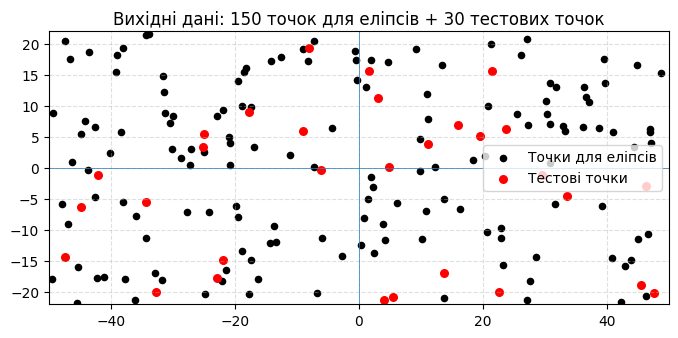

In [44]:
import numpy as np
import matplotlib.pyplot as plt

n_main = 150     
n_test = 30      
x_min, x_max = -50, 50
y_min, y_max = -22, 22
seed = 42      

np.random.seed(seed)

main_points = np.column_stack((
    np.random.uniform(x_min, x_max, n_main),
    np.random.uniform(y_min, y_max, n_main)
))

test_points = np.column_stack((
    np.random.uniform(x_min, x_max, n_test),
    np.random.uniform(y_min, y_max, n_test)
))

plt.figure(figsize=(8, 6))

plt.scatter(main_points[:, 0], main_points[:, 1],
            color='black', label='Точки для еліпсів', s=20)

plt.scatter(test_points[:, 0], test_points[:, 1],
            color='red', marker='o', label='Тестові точки', s=30)

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title(f'Вихідні дані: {n_main} точок для еліпсів + {n_test} тестових точок')

plt.show()

## Дві найвіддаленіші точки 

In [45]:
def cross(o, a, b):
    """Векторний добуток (a - o) x (b - o). > 0 — лівий поворот, < 0 — правий."""
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def convex_hull(points):
    """
    Опукла оболонка за алгоритмом Грехема (Graham scan).
    """
    pts = np.asarray(points)
    n = len(pts)
    if n < 3:
        return np.arange(n)

    # нижня ліва точка - гарантовано на оболонці
    idx_ymin = np.argmin(pts[:, 1])
    y_min = pts[:, 1].min()
    cand = np.where(pts[:, 1] == y_min)[0]
    start = cand[np.argmin(pts[cand, 0])]

    # сортування за полярним кутом відносно start; при однаковому куті - далі спочатку
    angles = np.arctan2(pts[:, 1] - pts[start, 1], pts[:, 0] - pts[start, 0])
    dists = np.sum((pts - pts[start]) ** 2, axis=1)
    order = np.lexsort((-dists, angles))
    order = order[order != start]
    order = np.concatenate([[start], order])

    stack = [order[0], order[1]]
    for i in range(2, n):
        k = order[i]
        while len(stack) >= 2 and cross(pts[stack[-2]], pts[stack[-1]], pts[k]) <= 0:
            stack.pop()
        stack.append(k)

    return np.array(stack)


# оболонка для main_points
hull_vertices_idx = convex_hull(main_points)
hull_vertices = main_points[hull_vertices_idx]

# пара з максимальною відстанню
n_hull = len(hull_vertices_idx)
max_dist = 0
idx_a, idx_b = 0, 0
for i in range(n_hull):
    for j in range(i + 1, n_hull):
        d = np.linalg.norm(hull_vertices[i] - hull_vertices[j])
        if d > max_dist:
            max_dist = d
            idx_a, idx_b = i, j

i_main = hull_vertices_idx[idx_a]
j_main = hull_vertices_idx[idx_b]
far_1 = main_points[i_main]
far_2 = main_points[j_main]

print(f"Дві найвіддаленіші точки: {far_1} та {far_2}")
print(f"Відстань: {max_dist:.4f}")

Дві найвіддаленіші точки: [48.68869366 15.36583006] та [-49.44778829 -17.87831022]
Відстань: 103.6144


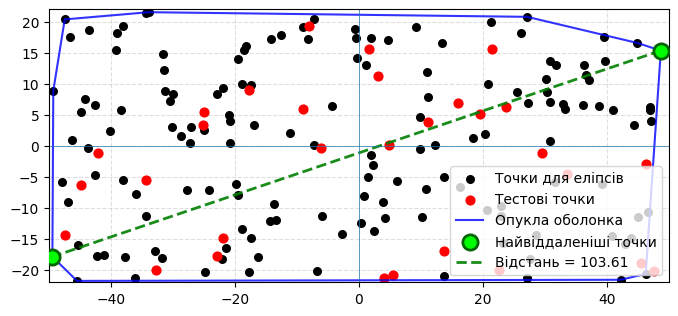

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(main_points[:, 0], main_points[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_points[:, 0], test_points[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)

# Опукла оболонка (замкнений контур)
hull_cycle = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_points[hull_cycle, 0], main_points[hull_cycle, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')

# дві найвіддаленіші точки та відрізок між ними
plt.scatter([far_1[0], far_2[0]], [far_1[1], far_2[1]], color='lime', s=120, edgecolors='darkgreen', linewidths=2, label='Найвіддаленіші точки', zorder=5)
plt.plot([far_1[0], far_2[0]], [far_1[1], far_2[1]], 'g--', linewidth=2, alpha=0.9, label=f'Відстань = {max_dist:.2f}')

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

## Поворот системи координат

Повертаємо СК так, щоб пряма між двома найвіддаленішими точками стала горизонтальною. Напрямок цієї прямої: **d** = far_2 − far_1. Кут напрямку до осі Ox: θ = atan2(dy, dx). Матриця повороту на кут **−θ**

$$R = \begin{pmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{pmatrix}$$

Нові координати: **p'** = R **p** (для кожної точки).

In [46]:
# Напрямок прямої найвіддаленіших точок і кут з віссю Ox
d = far_2 - far_1
# Щоб поворот був мінімальним d має вказувати вправо (d[0] > 0)
if d[0] < 0:
    d = -d
theta = np.arctan2(d[1], d[0])

# Матриця повороту на −θ: після повороту вектор d співпадає з віссю Ox
c, s = np.cos(theta), np.sin(theta)
R = np.array([[c, s], [-s, c]])

# Застосовуємо поворот до всіх точок: p' = R @ p
main_points_rot = (R @ main_points.T).T
test_points_rot = (R @ test_points.T).T
far_1_rot = R @ far_1
far_2_rot = R @ far_2

print(f"Після повороту: far_1_rot = {far_1_rot}, far_2_rot = {far_2_rot}")
print(f"Різниця y (має бути ~0): {abs(far_1_rot[1] - far_2_rot[1]):.2e}")

Після повороту: far_1_rot = [51.04465589 -1.06804911], far_2_rot = [-52.56973477  -1.06804911]
Різниця y (має бути ~0): 3.55e-15


## Дві найвіддаленіші точки по різні боки від прямої та перпендикуляри

Знаходимо по одній точці з кожного боку горизонтальної прямої (найвіддаленіші від неї) і проводимо з них перпендикуляри до прямої. У повернутій СК пряма горизонтальна, тому відстань до неї — це |y − y_прямої|, а перпендикуляр — вертикальний відрізок.

In [47]:
# Пряма в повернутій СК горизонтальна: y = y_line
y_line = far_1_rot[1]
all_rot = np.vstack([main_points_rot, test_points_rot])

# Розділяємо точки на «вище» та «нижче» прямої
above_mask = all_rot[:, 1] > y_line
below_mask = all_rot[:, 1] < y_line

# Найвіддаленіша точка вище прямої (макс. (y - y_line))
point_above = None
if above_mask.any():
    idx_in_above = np.argmax(all_rot[above_mask, 1] - y_line)
    point_above = all_rot[above_mask][idx_in_above]

# Найвіддаленіша точка нижче прямої (макс. (y_line - y))
point_below = None
if below_mask.any():
    idx_in_below = np.argmax(y_line - all_rot[below_mask, 1])
    point_below = all_rot[below_mask][idx_in_below]

dist_above = (point_above[1] - y_line) if point_above is not None else 0
dist_below = (y_line - point_below[1]) if point_below is not None else 0
print(f"Точка вище прямої: {point_above}, відстань = {dist_above:.4f}")
print(f"Точка нижче прямої: {point_below}, відстань = {dist_below:.4f}")

Точка вище прямої: [-38.40405963  34.54748673], відстань = 35.6155
Точка нижче прямої: [ 38.58585208 -34.40704257], відстань = 33.3390


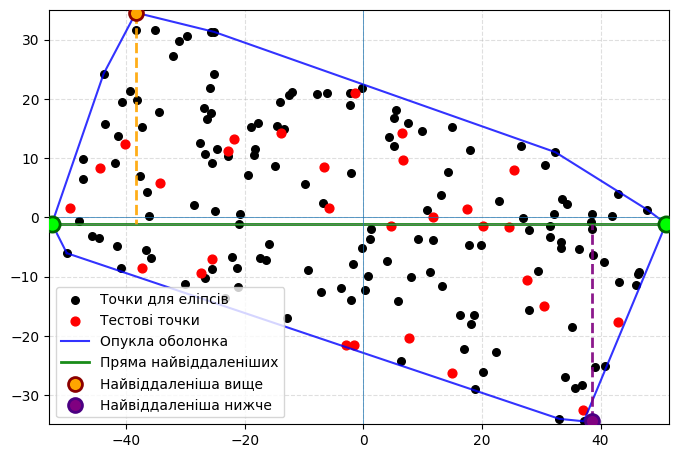

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(main_points_rot[:, 0], main_points_rot[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_points_rot[:, 0], test_points_rot[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)

hull_cycle_rot = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_points_rot[hull_cycle_rot, 0], main_points_rot[hull_cycle_rot, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')

# Горизонтальна пряма та найвіддаленіші точки на ній
plt.scatter([far_1_rot[0], far_2_rot[0]], [far_1_rot[1], far_2_rot[1]], color='lime', s=120, edgecolors='darkgreen', linewidths=2, zorder=5)
plt.plot([far_1_rot[0], far_2_rot[0]], [far_1_rot[1], far_2_rot[1]], 'g-', linewidth=2, alpha=0.9, label='Пряма найвіддаленіших')

# Дві точки по різні боки та перпендикуляри (вертикальні відрізки до прямої y = y_line)
if point_above is not None:
    plt.scatter(*point_above, color='orange', s=100, edgecolors='darkred', linewidths=2, label='Найвіддаленіша вище', zorder=5)
    plt.plot([point_above[0], point_above[0]], [point_above[1], y_line], 'orange', linestyle='--', linewidth=2, alpha=0.9)
if point_below is not None:
    plt.scatter(*point_below, color='purple', s=100, edgecolors='indigo', linewidths=2, label='Найвіддаленіша нижче', zorder=5)
    plt.plot([point_below[0], point_below[0]], [point_below[1], y_line], 'purple', linestyle='--', linewidth=2, alpha=0.9)

plt.axhline(y_line, color='gray', linewidth=0.8, alpha=0.6)
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
all_rot = np.vstack([main_points_rot, test_points_rot])
pad = 0.5
plt.xlim(all_rot[:, 0].min() - pad, all_rot[:, 0].max() + pad)
plt.ylim(all_rot[:, 1].min() - pad, all_rot[:, 1].max() + pad)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

## 4. Приведення до квадратної області

Область масштабується так, щоб **ширина = висота** і **центр зберігався**.  
Формула: **x'_i = (x_i − x_c) / k + x_c**, де **k** — коефіцієнт стискання по більшій осі (k = більша_вісь / менша_вісь). Стискаємо лише більшу вісь.

In [48]:
# Область (bounding box) у повернутій СК
all_rot = np.vstack([main_points_rot, test_points_rot])
x_min, x_max = all_rot[:, 0].min(), all_rot[:, 0].max()
y_min, y_max = all_rot[:, 1].min(), all_rot[:, 1].max()
width = x_max - x_min
height = y_max - y_min

# Центр та коефіцієнт стискання по більшій осі
x_c = (x_min + x_max) / 2
y_c = (y_min + y_max) / 2
k = max(width, height) / min(width, height)

def scale_to_square(pts, x_c, y_c, k, scale_x):
    pts = np.asarray(pts)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    out = pts.copy()
    if scale_x:
        out[:, 0] = (pts[:, 0] - x_c) / k + x_c
    else:
        out[:, 1] = (pts[:, 1] - y_c) / k + y_c
    return out.squeeze()

scale_x = width >= height  # стискаємо більшу вісь

# Застосовуємо масштабування до всіх точок
main_sq = scale_to_square(main_points_rot, x_c, y_c, k, scale_x)
test_sq = scale_to_square(test_points_rot, x_c, y_c, k, scale_x)
far_1_sq = scale_to_square(far_1_rot, x_c, y_c, k, scale_x)
far_2_sq = scale_to_square(far_2_rot, x_c, y_c, k, scale_x)
if point_above is not None:
    point_above_sq = scale_to_square(point_above, x_c, y_c, k, scale_x)
else:
    point_above_sq = None
if point_below is not None:
    point_below_sq = scale_to_square(point_below, x_c, y_c, k, scale_x)
else:
    point_below_sq = None

# Рівень горизонтальної прямої після масштабування
y_line_sq = (y_line - y_c) / k + y_c if not scale_x else y_line

print(f"Центр (x_c, y_c) = ({x_c:.4f}, {y_c:.4f}), k = {k:.4f}, стиск по осі: {'x' if scale_x else 'y'}")

Центр (x_c, y_c) = (-0.7625, 0.0702), k = 1.5026, стиск по осі: x


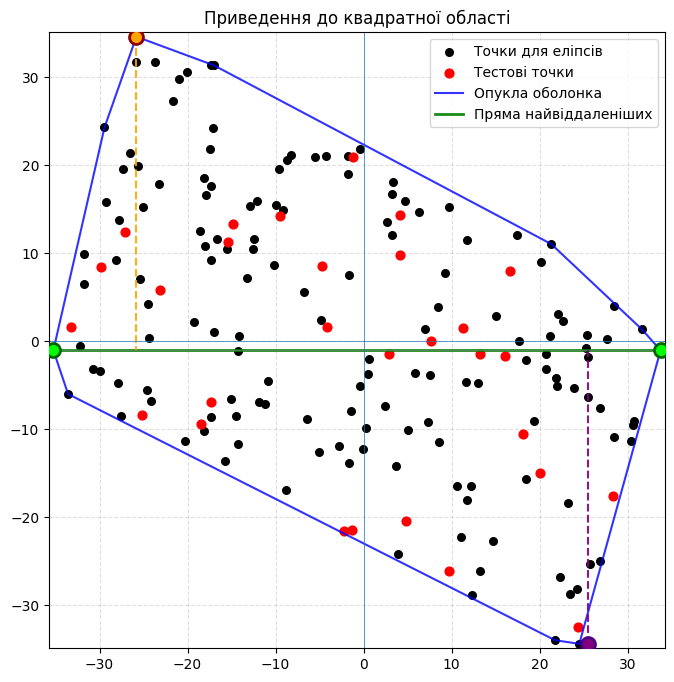

In [49]:
# Візуалізація: квадратна область
all_sq = np.vstack([main_sq, test_sq])
pad = 0.5
x_lo, x_hi = all_sq[:, 0].min() - pad, all_sq[:, 0].max() + pad
y_lo, y_hi = all_sq[:, 1].min() - pad, all_sq[:, 1].max() + pad
# Показати квадратну форму осей
r = max(x_hi - x_lo, y_hi - y_lo) / 2
mid_x = (x_lo + x_hi) / 2
mid_y = (y_lo + y_hi) / 2
plt.figure(figsize=(8, 8))
plt.scatter(main_sq[:, 0], main_sq[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_sq[:, 0], test_sq[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)
hull_cycle_rot = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_sq[hull_cycle_rot, 0], main_sq[hull_cycle_rot, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')
plt.scatter([far_1_sq[0], far_2_sq[0]], [far_1_sq[1], far_2_sq[1]], color='lime', s=100, edgecolors='darkgreen', linewidths=2, zorder=5)
plt.plot([far_1_sq[0], far_2_sq[0]], [far_1_sq[1], far_2_sq[1]], 'g-', linewidth=2, alpha=0.9, label='Пряма найвіддаленіших')
plt.axhline(y_line_sq, color='gray', linewidth=0.8, alpha=0.6)
if point_above_sq is not None:
    plt.scatter(*point_above_sq, color='orange', s=100, edgecolors='darkred', linewidths=2, zorder=5)
    plt.plot([point_above_sq[0], point_above_sq[0]], [point_above_sq[1], y_line_sq], 'orange', linestyle='--', linewidth=1.5, alpha=0.9)
if point_below_sq is not None:
    plt.scatter(*point_below_sq, color='purple', s=100, edgecolors='indigo', linewidths=2, zorder=5)
    plt.plot([point_below_sq[0], point_below_sq[0]], [point_below_sq[1], y_line_sq], 'purple', linestyle='--', linewidth=1.5, alpha=0.9)
plt.xlim(mid_x - r, mid_x + r)
plt.ylim(mid_y - r, mid_y + r)
plt.gca().set_aspect('equal', adjustable='box')
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title('Приведення до квадратної області')
plt.show()

## 5. Побудова вкладених кіл

У центрі квадрату будується система кіл:
- **центр** — центр квадратної області (x_c, y_c);
- **радіуси** дорівнюють відстаням від центру до кожної точки множини (main_sq).

Отримуємо впорядковані радіуси: r_1 ≤ r_2 ≤ … ≤ r_n.

In [50]:
# Центр квадратної області
center_sq = np.array([x_c, y_c])

# Відстані від центру до кожної точки множини main_sq
distances = np.linalg.norm(main_sq - center_sq, axis=1)

# Впорядковані радіуси: r_1 <= r_2 <= ... <= r_n
radii_ordered = np.sort(distances)
# Унікальні радіуси для малювання кіл (без дублікатів)
radii_unique = np.unique(radii_ordered)

print(f"Центр кіл: {center_sq}")
print(f"Кількість радіусів (точок): {len(radii_ordered)}, унікальних кіл: {len(radii_unique)}")
print(f"Радіуси (перші 5 та останні 5): {radii_ordered[:5]} ... {radii_ordered[-5:]}")

Центр кіл: [-0.76253944  0.07022208]
Кількість радіусів (точок): 150, унікальних кіл: 149
Радіуси (перші 5 та останні 5): [2.51230717 3.99804591 4.69297304 5.25813573 7.44347025] ... [39.02229314 40.30745456 40.81342643 42.61678633 42.72855386]


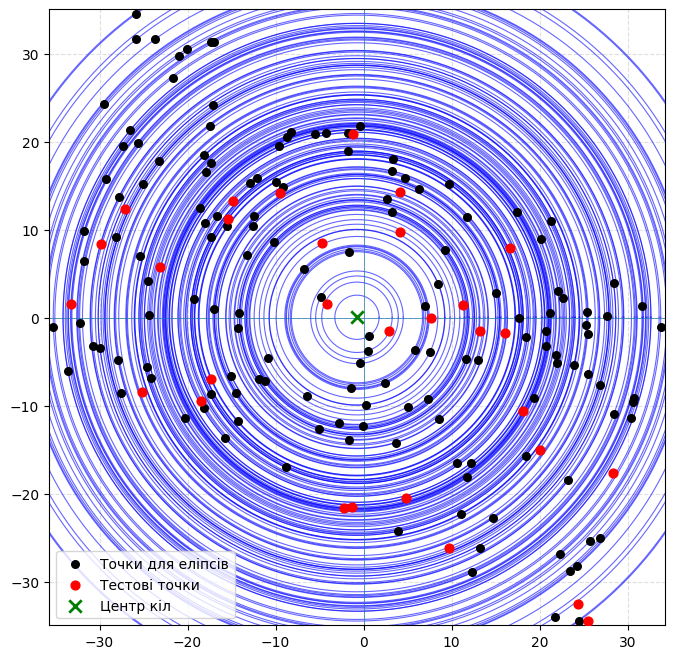

In [39]:
# вкладені кола в центрі квадрату
fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2 * np.pi, 200)
for r in radii_unique:
    ax.plot(x_c + r * np.cos(theta), y_c + r * np.sin(theta), 'b-', linewidth=0.8, alpha=0.6)
ax.scatter(main_sq[:, 0], main_sq[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=3)
ax.scatter(test_sq[:, 0], test_sq[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=3)
ax.scatter(*center_sq, color='green', s=80, marker='x', linewidths=2, label='Центр кіл', zorder=4)
all_sq = np.vstack([main_sq, test_sq])
pad = 0.5
r_plot = max(all_sq[:, 0].max() - x_c, x_c - all_sq[:, 0].min(), all_sq[:, 1].max() - y_c, y_c - all_sq[:, 1].min()) + pad
ax.set_xlim(x_c - r_plot, x_c + r_plot)
ax.set_ylim(y_c - r_plot, y_c + r_plot)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.show()

## 6. Перевірка тестових точок

Для кожної тестової точки визначаємо:
- **у скількох колах вона лежить**
- **номер максимального кола, яке її містить**

**Перевірка:** точка (x, y) лежить всередині або на колі радіуса r з центром (x_c, y_c), якщо  
(x − x_c)² + (y − y_c)² ≤ r².

In [51]:
# Відстані від центру до кожної тестової точки
dist_test = np.linalg.norm(test_sq - center_sq, axis=1)

# Для кожної тестової точки: кількість кіл, у яких вона лежить, та номер максимального кола
# Коло k (1-based) має радіус radii_ordered[k-1]. Точка всередині кола k ⟺ dist ≤ radii_ordered[k-1].
num_circles_per_point = np.sum(radii_ordered[:, np.newaxis] >= dist_test, axis=0)  # shape (n_test,)
max_circle_per_point = num_circles_per_point  # номер макс. кола = кількість кіл, що містять точку

print("Тестові точки (квадратні координати), кількість кіл")
for i in range(len(test_sq)):
    print(f"  Точка {i+1}: ({test_sq[i, 0]:.4f}, {test_sq[i, 1]:.4f}) — у {num_circles_per_point[i]} колах")

Тестові точки (квадратні координати), кількість кіл
  Точка 1: (-29.8661, 8.3819) — у 33 колах
  Точка 2: (4.1437, 9.7394) — у 136 колах
  Точка 3: (-2.2560, -21.5408) — у 80 колах
  Точка 4: (4.8003, -20.4091) — у 84 колах
  Точка 5: (9.7304, -26.1738) — у 44 колах
  Точка 6: (25.4235, -34.4070) — у 0 колах
  Точка 7: (4.1119, 14.2904) — у 116 колах
  Точка 8: (-9.5009, 14.1675) — у 109 колах
  Точка 9: (18.1081, -10.5472) — у 80 колах
  Точка 10: (-18.4780, -9.4070) — у 89 колах
  Точка 11: (-4.1805, 1.6087) — у 149 колах
  Точка 12: (-27.0746, 12.4195) — у 38 колах
  Точка 13: (-33.2428, 1.6100) — у 25 колах
  Точка 14: (28.2846, -17.6005) — у 18 колах
  Точка 15: (19.9685, -15.0094) — у 52 колах
  Точка 16: (13.1857, -1.4598) — у 120 колах
  Точка 17: (-4.7247, 8.5511) — у 139 колах
  Точка 18: (-25.1194, -8.4667) — у 52 колах
  Точка 19: (-23.0881, 5.7977) — у 68 колах
  Точка 20: (-14.8150, 13.2584) — у 94 колах
  Точка 21: (2.8772, -1.4487) — у 149 колах
  Точка 22: (16.6203, 7.

## 7. Зворотне масштабування та ймовірність належності

Кола перетворюються назад у прямокутну область → вони стають **еліпсами**. Таким чином отримуємо систему вкладених еліпсів.

**Ймовірність належності:** якщо точка знаходиться в m-му еліпсі (з n можливих):  
**P = (m − 1) / (n + 1)**

Граничні випадки: внутрішнє коло → P ≈ 0, зовнішнє → P ≈ 1.

In [52]:
n = len(radii_ordered)  # кількість еліпсів

# Ймовірність належності для кожної тестової точки з обробкою граничних випадків
# P = (m - 1) / (n + 1), де m — номер макс. кола, що містить точку
# Граничні випадки: m=0 → P=0 (в центрі), m≥n → P=1 (зовні)
P_test = np.zeros(len(test_sq))
statuses = []

for i in range(len(test_sq)):
    m = max_circle_per_point[i]
    
    if m == 0:
        # Точка всередині найменшого кола
        P_test[i] = 0.0
        statuses.append("внутрішня (центр)")
    elif m >= n:
        # Точка зовні всіх кіл
        P_test[i] = 1.0
        statuses.append("зовнішня (край)")
    else:
        # Нормальний випадок
        P_test[i] = (m - 1) / (n + 1)
        statuses.append(f"m={m}/{n}")

print("Результат: ймовірність належності тестових точок")
print(f"{'№':<3} {'m':<3} {'P':<8} {'Статус':<25}")
print("-" * 45)
for i in range(len(test_sq)):
    m = max_circle_per_point[i]
    print(f"{i+1:<3} {m:<3} {P_test[i]:<8.4f} {statuses[i]:<25}")

# Статистика
n_center = sum(1 for s in statuses if "центр" in s)
n_edge = sum(1 for s in statuses if "край" in s)
n_middle = len(statuses) - n_center - n_edge
print(f"\nСтатистика: {n_center} в центрі, {n_middle} у середині, {n_edge} на краю, середня P = {P_test.mean():.4f}")

Результат: ймовірність належності тестових точок
№   m   P        Статус                   
---------------------------------------------
1   33  0.2119   m=33/150                 
2   136 0.8940   m=136/150                
3   80  0.5232   m=80/150                 
4   84  0.5497   m=84/150                 
5   44  0.2848   m=44/150                 
6   0   0.0000   внутрішня (центр)        
7   116 0.7616   m=116/150                
8   109 0.7152   m=109/150                
9   80  0.5232   m=80/150                 
10  89  0.5828   m=89/150                 
11  149 0.9801   m=149/150                
12  38  0.2450   m=38/150                 
13  25  0.1589   m=25/150                 
14  18  0.1126   m=18/150                 
15  52  0.3377   m=52/150                 
16  120 0.7881   m=120/150                
17  139 0.9139   m=139/150                
18  52  0.3377   m=52/150                 
19  68  0.4437   m=68/150                 
20  94  0.6159   m=94/150                 
21

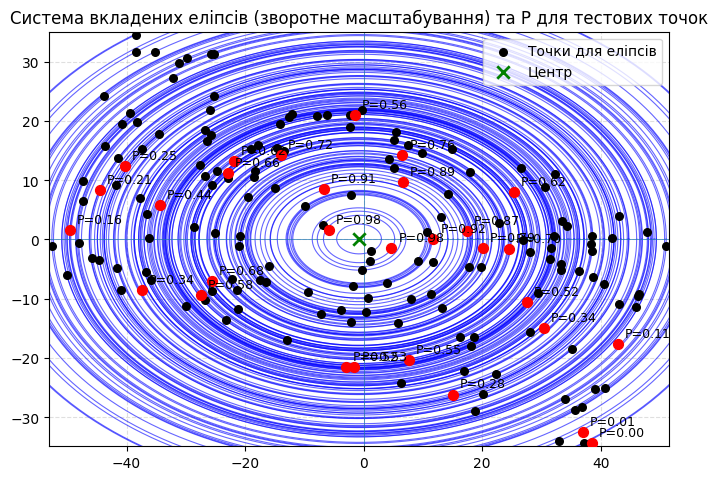

In [54]:
# Зворотне масштабування: кола в квадраті - еліпси в повернутій області
# Еліпс з кола радіуса r: півосі a, b (стискали одну вісь на k, тому обернено одна піввісь у k разів більша)
theta = np.linspace(0, 2 * np.pi, 200)
if scale_x:
    a_mult, b_mult = k, 1.0   # по x розтягуємо назад у k разів
else:
    a_mult, b_mult = 1.0, k   # по y розтягуємо назад у k разів

fig, ax = plt.subplots(figsize=(8, 6))
for r in radii_unique:
    ax.plot(x_c + a_mult * r * np.cos(theta), y_c + b_mult * r * np.sin(theta), 'b-', linewidth=0.8, alpha=0.6)
ax.scatter(main_points_rot[:, 0], main_points_rot[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=3)
ax.scatter(test_points_rot[:, 0], test_points_rot[:, 1], color='red', s=50, zorder=3)
for i in range(len(test_points_rot)):
    ax.annotate(f'P={P_test[i]:.2f}', (test_points_rot[i, 0], test_points_rot[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.scatter(x_c, y_c, color='green', s=80, marker='x', linewidths=2, label='Центр', zorder=4)
all_rot = np.vstack([main_points_rot, test_points_rot])
pad = 0.5
ax.set_xlim(all_rot[:, 0].min() - pad, all_rot[:, 0].max() + pad)
ax.set_ylim(all_rot[:, 1].min() - pad, all_rot[:, 1].max() + pad)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
ax.set_title('Система вкладених еліпсів (зворотне масштабування) та P для тестових точок')
plt.show()


## 8. Розрахунок площ еліпсів

Для кожного еліпса з радіусом r у повернутій системі координат обчислюємо дві півосі:
- Якщо стискали по x: $a = k \cdot r$, $b = r$
- Якщо стискали по y: $a = r$, $b = k \cdot r$

Площа еліпса: $S = \pi \cdot a \cdot b$


In [53]:

# Розрахунок площ еліпсів
# Для кожного кола радіуса r у повернутій СК визначаємо полуосі еліпса після зворотного стискання

ellipse_areas = []
ellipse_params = []

for r in radii_unique:
    if scale_x:
        # Стискали по x, тому розтягуємо назад: a = k*r, b = r
        a = k * r
        b = r
    else:
        # Стискали по y, тому розтягуємо назад: a = r, b = k*r
        a = r
        b = k * r
    
    area = np.pi * a * b
    ellipse_areas.append(area)
    ellipse_params.append((a, b, r))

ellipse_areas = np.array(ellipse_areas)

print("Параметри еліпсів:")
print(f"{'№':<3} {'a (піввісь)':<15} {'b (піввісь)':<15} {'r (круг)':<12} {'Площа':<12}")
print("-" * 60)
for i, (a, b, r) in enumerate(ellipse_params[:10]):  # показуємо перші 10
    area = np.pi * a * b
    print(f"{i+1:<3} {a:<15.4f} {b:<15.4f} {r:<12.4f} {area:<12.2f}")
if len(ellipse_params) > 10:
    print(f"... (ще {len(ellipse_params) - 10} еліпсів)")
    a, b, r = ellipse_params[-1]
    area = np.pi * a * b
    print(f"{len(ellipse_params):<3} {a:<15.4f} {b:<15.4f} {r:<12.4f} {area:<12.2f}")


Параметри еліпсів:
№   a (піввісь)     b (піввісь)     r (круг)     Площа       
------------------------------------------------------------
1   3.7751          2.5123          2.5123       29.80       
2   6.0077          3.9980          3.9980       75.46       
3   7.0519          4.6930          4.6930       103.97      
4   7.9011          5.2581          5.2581       130.52      
5   11.1849         7.4435          7.4435       261.55      
6   11.3867         7.5778          7.5778       271.08      
7   11.6831         7.7750          7.7750       285.37      
8   12.0258         8.0031          8.0031       302.36      
9   12.1505         8.0860          8.0860       308.66      
10  12.3206         8.1993          8.1993       317.36      
... (ще 139 еліпсів)
149 64.2060         42.7286         42.7286      8618.74     


In [55]:

# Експорт графіків для LaTeX звіту
import os

# Створити папку для графіків
os.makedirs('figures', exist_ok=True)

# Fig 1: Вихідні точки
plt.figure(figsize=(8, 6))
plt.scatter(main_points[:, 0], main_points[:, 1], color='black', label='Точки для еліпсів', s=20)
plt.scatter(test_points[:, 0], test_points[:, 1], color='red', marker='o', label='Тестові точки', s=30)
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title(f'Вихідні дані: {n_main} точок для еліпсів + {n_test} тестових точок')
plt.tight_layout()
plt.savefig('figures/fig1_input_points.png', dpi=150, bbox_inches='tight')
plt.close()

# Fig 2: Опукла оболонка
plt.figure(figsize=(8, 6))
plt.scatter(main_points[:, 0], main_points[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_points[:, 0], test_points[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)
hull_cycle = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_points[hull_cycle, 0], main_points[hull_cycle, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')
plt.scatter([far_1[0], far_2[0]], [far_1[1], far_2[1]], color='lime', s=120, edgecolors='darkgreen', linewidths=2, label='Найвіддаленіші точки', zorder=5)
plt.plot([far_1[0], far_2[0]], [far_1[1], far_2[1]], 'g--', linewidth=2, alpha=0.9, label=f'Відстань = {max_dist:.2f}')
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title('Опукла оболонка та дві найвіддаленіші точки')
plt.tight_layout()
plt.savefig('figures/fig2_convex_hull.png', dpi=150, bbox_inches='tight')
plt.close()

# Fig 3: Перпендикуляри
plt.figure(figsize=(8, 6))
plt.scatter(main_points_rot[:, 0], main_points_rot[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_points_rot[:, 0], test_points_rot[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)
hull_cycle_rot = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_points_rot[hull_cycle_rot, 0], main_points_rot[hull_cycle_rot, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')
plt.scatter([far_1_rot[0], far_2_rot[0]], [far_1_rot[1], far_2_rot[1]], color='lime', s=120, edgecolors='darkgreen', linewidths=2, zorder=5)
plt.plot([far_1_rot[0], far_2_rot[0]], [far_1_rot[1], far_2_rot[1]], 'g-', linewidth=2, alpha=0.9, label='Пряма найвіддаленіших')
if point_above is not None:
    plt.scatter(*point_above, color='orange', s=100, edgecolors='darkred', linewidths=2, label='Найвіддаленіша вище', zorder=5)
    plt.plot([point_above[0], point_above[0]], [point_above[1], y_line], 'orange', linestyle='--', linewidth=2, alpha=0.9)
if point_below is not None:
    plt.scatter(*point_below, color='purple', s=100, edgecolors='indigo', linewidths=2, label='Найвіддаленіша нижче', zorder=5)
    plt.plot([point_below[0], point_below[0]], [point_below[1], y_line], 'purple', linestyle='--', linewidth=2, alpha=0.9)
plt.axhline(y_line, color='gray', linewidth=0.8, alpha=0.6)
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
all_rot_temp = np.vstack([main_points_rot, test_points_rot])
pad = 0.5
plt.xlim(all_rot_temp[:, 0].min() - pad, all_rot_temp[:, 0].max() + pad)
plt.ylim(all_rot_temp[:, 1].min() - pad, all_rot_temp[:, 1].max() + pad)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title('Перпендикуляри до прямої')
plt.tight_layout()
plt.savefig('figures/fig3_perpendiculars.png', dpi=150, bbox_inches='tight')
plt.close()

# Fig 4: Квадратна область
all_sq_temp = np.vstack([main_sq, test_sq])
pad = 0.5
x_lo, x_hi = all_sq_temp[:, 0].min() - pad, all_sq_temp[:, 0].max() + pad
y_lo, y_hi = all_sq_temp[:, 1].min() - pad, all_sq_temp[:, 1].max() + pad
r = max(x_hi - x_lo, y_hi - y_lo) / 2
mid_x = (x_lo + x_hi) / 2
mid_y = (y_lo + y_hi) / 2
plt.figure(figsize=(8, 8))
plt.scatter(main_sq[:, 0], main_sq[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_sq[:, 0], test_sq[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)
hull_cycle_rot = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_sq[hull_cycle_rot, 0], main_sq[hull_cycle_rot, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')
plt.scatter([far_1_sq[0], far_2_sq[0]], [far_1_sq[1], far_2_sq[1]], color='lime', s=100, edgecolors='darkgreen', linewidths=2, zorder=5)
plt.plot([far_1_sq[0], far_2_sq[0]], [far_1_sq[1], far_2_sq[1]], 'g-', linewidth=2, alpha=0.9, label='Пряма найвіддаленіших')
plt.xlim(mid_x - r, mid_x + r)
plt.ylim(mid_y - r, mid_y + r)
plt.gca().set_aspect('equal', adjustable='box')
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title('Приведення до квадратної області')
plt.tight_layout()
plt.savefig('figures/fig4_square_scaling.png', dpi=150, bbox_inches='tight')
plt.close()

# Fig 5: Вкладені кола
fig, ax = plt.subplots(figsize=(8, 8))
theta_circles = np.linspace(0, 2 * np.pi, 200)
for r in radii_unique:
    ax.plot(x_c + r * np.cos(theta_circles), y_c + r * np.sin(theta_circles), 'b-', linewidth=0.8, alpha=0.6)
ax.scatter(main_sq[:, 0], main_sq[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=3)
ax.scatter(test_sq[:, 0], test_sq[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=3)
ax.scatter(*center_sq, color='green', s=80, marker='x', linewidths=2, label='Центр кіл', zorder=4)
all_sq_temp = np.vstack([main_sq, test_sq])
pad = 0.5
r_plot = max(all_sq_temp[:, 0].max() - x_c, x_c - all_sq_temp[:, 0].min(), all_sq_temp[:, 1].max() - y_c, y_c - all_sq_temp[:, 1].min()) + pad
ax.set_xlim(x_c - r_plot, x_c + r_plot)
ax.set_ylim(y_c - r_plot, y_c + r_plot)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
ax.set_title('Система вкладених кіл')
plt.tight_layout()
plt.savefig('figures/fig5_nested_circles.png', dpi=150, bbox_inches='tight')
plt.close()

# Fig 6: Еліпси з ймовірностями
theta_ellipses = np.linspace(0, 2 * np.pi, 200)
if scale_x:
    a_mult_final, b_mult_final = k, 1.0
else:
    a_mult_final, b_mult_final = 1.0, k
fig, ax = plt.subplots(figsize=(8, 6))
for r in radii_unique:
    ax.plot(x_c + a_mult_final * r * np.cos(theta_ellipses), y_c + b_mult_final * r * np.sin(theta_ellipses), 'b-', linewidth=0.8, alpha=0.6)
ax.scatter(main_points_rot[:, 0], main_points_rot[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=3)
ax.scatter(test_points_rot[:, 0], test_points_rot[:, 1], color='red', s=50, zorder=3)
for i in range(len(test_points_rot)):
    ax.annotate(f'P={P_test[i]:.2f}', (test_points_rot[i, 0], test_points_rot[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.scatter(x_c, y_c, color='green', s=80, marker='x', linewidths=2, label='Центр', zorder=4)
all_rot_temp = np.vstack([main_points_rot, test_points_rot])
pad = 0.5
ax.set_xlim(all_rot_temp[:, 0].min() - pad, all_rot_temp[:, 0].max() + pad)
ax.set_ylim(all_rot_temp[:, 1].min() - pad, all_rot_temp[:, 1].max() + pad)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
ax.set_title('Система вкладених еліпсів та ймовірності')
plt.tight_layout()
plt.savefig('figures/fig6_nested_ellipses.png', dpi=150, bbox_inches='tight')
plt.close()

# Fig 7: Графіки площі та радіуса
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, len(ellipse_areas) + 1), ellipse_areas, 'b.-', markersize=4, linewidth=1)
ax1.set_xlabel('Номер еліпса')
ax1.set_ylabel('Площа')
ax1.set_title('Залежність площі еліпса від номеру')
ax1.grid(True, alpha=0.3)
radii_plot_final = radii_unique
ax2.plot(range(1, len(radii_plot_final) + 1), radii_plot_final, 'g.-', markersize=4, linewidth=1)
ax2.set_xlabel('Номер кола')
ax2.set_ylabel('Радіус')
ax2.set_title('Залежність радіуса від номеру кола')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fig7_ellipse_properties.png', dpi=150, bbox_inches='tight')
plt.close()

print("\n✓✓✓ ЕКСПОРТ ЗАВЕРШЕНО ✓✓✓")
print("Графіки експортовані у папку 'figures/':")
print("  - fig1_input_points.png")
print("  - fig2_convex_hull.png")
print("  - fig3_perpendiculars.png")
print("  - fig4_square_scaling.png")
print("  - fig5_nested_circles.png")
print("  - fig6_nested_ellipses.png")
print("  - fig7_ellipse_properties.png")
print("\nЛаTeX звіт: REPORT.tex")
print("Для компіляції: pdflatex REPORT.tex")


✓✓✓ ЕКСПОРТ ЗАВЕРШЕНО ✓✓✓
Графіки експортовані у папку 'figures/':
  - fig1_input_points.png
  - fig2_convex_hull.png
  - fig3_perpendiculars.png
  - fig4_square_scaling.png
  - fig5_nested_circles.png
  - fig6_nested_ellipses.png
  - fig7_ellipse_properties.png

ЛаTeX звіт: REPORT.tex
Для компіляції: pdflatex REPORT.tex
